# BI_NGO - Working Dogs Foundation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Zbiór danych dotyczący cyklicznych płatności na rzecz fundacji

In [2]:
df = pd.read_csv('working_dogs_foundation-darczyncy_cykliczni.csv', index_col='id_darczyncy')

df.head()

,wysokosc_wplaty,sposob_platnosci
id_darczyncy,,
1,25,patronite
2,100,patronite
3,5,patronite
4,10,patronite
5,25,patronite


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 1 to 31
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   wysokosc_wplaty   31 non-null     int64 
 1   sposob_platnosci  31 non-null     object
dtypes: int64(1), object(1)
memory usage: 744.0+ bytes
None


In [4]:
display(df.wysokosc_wplaty.describe())

count     31.000000
mean      51.290323
std       89.921890
min        5.000000
25%       10.000000
50%       25.000000
75%       55.000000
max      500.000000
Name: wysokosc_wplaty, dtype: float64

#### Analiza wyników
- 31 darczyńców
- średnia > mediana, co sugeruje asymetrię prawostronną (czyli kilka dużych wpłat zawyża średnią)
- minimalna wpłata 5 złotych, maksymalna 100x więcej - 500 złotych
- większość wpłat jest raczej niewielka (10–55 zł)
- duże wpłaty są rzadkie, ale mają duży wpływ na średnią

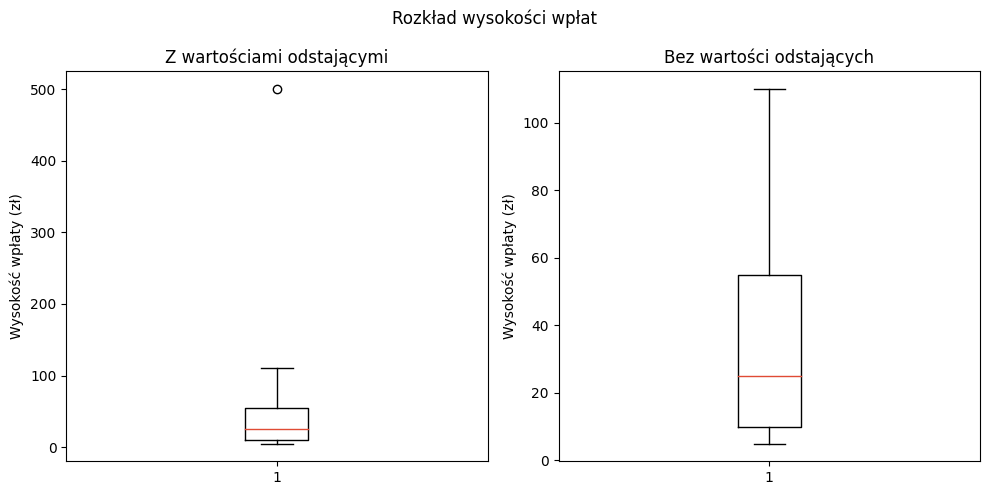

In [5]:
fig = plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.boxplot(df.wysokosc_wplaty, medianprops=dict(color='#e04b34'))
plt.title("Z wartościami odstającymi")
plt.ylabel("Wysokość wpłaty (zł)")


plt.subplot(1, 2, 2)
plt.boxplot(df.wysokosc_wplaty, showfliers=False, medianprops=dict(color='#e04b34'))
plt.title("Bez wartości odstających")
plt.ylabel("Wysokość wpłaty (zł)")

fig.suptitle('Rozkład wysokości wpłat')

plt.tight_layout()
plt.show()

### Zliczenie sposobów płatności

In [6]:
print(df["sposob_platnosci"].value_counts())

sposob_platnosci
Stripe       17
patronite    11
konto         3
Name: count, dtype: int64


### Procentowy udział sposobu płatności

In [7]:
print(df["sposob_platnosci"].value_counts(normalize=True) * 100)

sposob_platnosci
Stripe       54.838710
patronite    35.483871
konto         9.677419
Name: proportion, dtype: float64


#### Analiza wyników
- Dominującą metodą płatności jest Stripe – ponad połowa wszystkich wpłat
- Patronite również ma duży udział (ponad 1/3)
- Tradycyjny przelew (konto) ma marginalne znaczenie (~10%)

### Średnia wysokość wpłaty według różnych sposóbów płatności

In [8]:
df.groupby("sposob_platnosci")["wysokosc_wplaty"].mean()

sposob_platnosci
Stripe        33.235294
konto        208.333333
patronite     36.363636
Name: wysokosc_wplaty, dtype: float64

In [9]:
print(df["wysokosc_wplaty"].median())
print(df["wysokosc_wplaty"].mean())

25.0
51.29032258064516


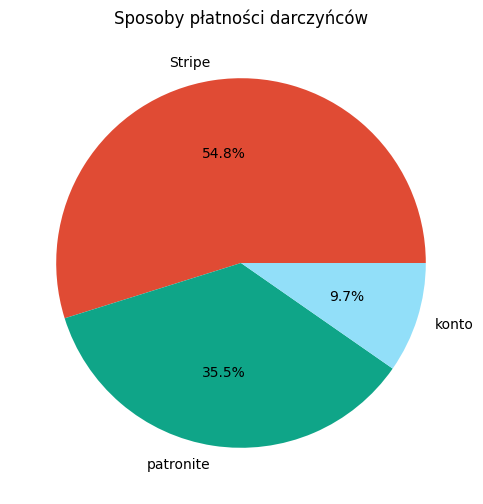

In [10]:
colors = ['#e04b34', '#0fa588', '#92dff9']

df["sposob_platnosci"].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6),
    colors=colors
)

plt.title("Sposoby płatności darczyńców")
plt.ylabel("")
plt.show()

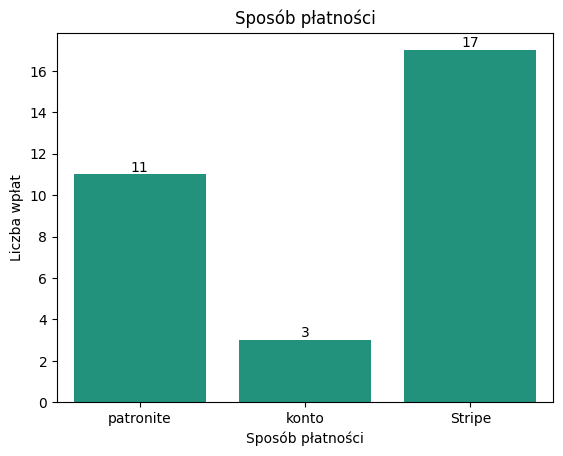

In [11]:
ax = sns.countplot(data=df, x="sposob_platnosci", color="#0fa588")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Sposób płatności")
plt.xlabel("Sposób płatności")
plt.ylabel("Liczba wpłat")
plt.show()

### Liczba i procent wpłat <= 10zl

In [12]:
male_wplaty = df[df["wysokosc_wplaty"] <= 10]

# liczba takich darczyńców
liczba = len(male_wplaty)

# procent
procent = (liczba / len(df)) * 100

print("Liczba darczyńców (<=10 zł):", liczba)
print("Procent:", round(procent, 1), "%")

Liczba darczyńców (<=10 zł): 9
Procent: 29.0 %


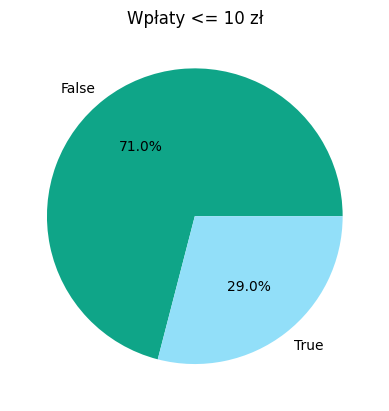

In [13]:
df["czy_mala_wplata"] = df["wysokosc_wplaty"] <= 10

df["czy_mala_wplata"].value_counts().plot.pie(autopct='%1.1f%%', colors=colors[1:])
plt.title("Wpłaty <= 10 zł")
plt.ylabel("")
plt.show()

### Liczba i procent wpłat <= 25zł

In [14]:
średnie_wplaty = df[df["wysokosc_wplaty"] <= 25]
liczba = len(male_wplaty)

# procent
procent = (liczba / len(df)) * 100

print("Liczba darczyńców (<=25 zł):", liczba)
print("Procent:", round(procent, 2), "%")

Liczba darczyńców (<=25 zł): 9
Procent: 29.03 %


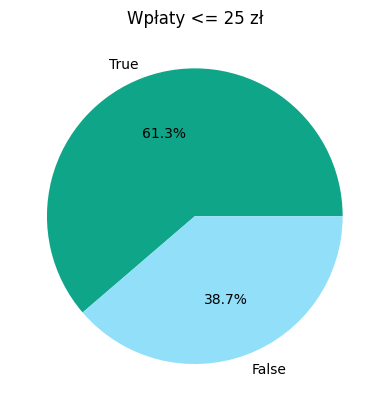

In [15]:
df["czy_srednia_wplata"] = df["wysokosc_wplaty"] <= 25

df["czy_srednia_wplata"].value_counts().plot.pie(autopct='%1.1f%%', colors=colors[1:])
plt.title("Wpłaty <= 25 zł")
plt.ylabel("")
plt.show()

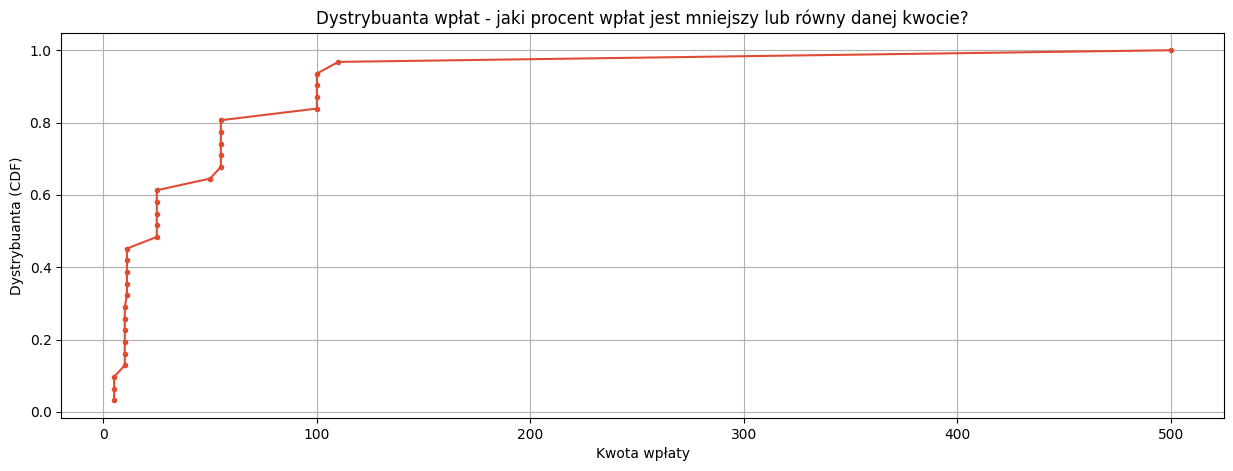

In [16]:
kwoty = np.array(df.wysokosc_wplaty)

# sortowanie danych
x = np.sort(kwoty)

# dystrybuanta (CDF)
y = np.arange(1, len(x)+1) / len(x)

# wykres
plt.figure(figsize=(15,5))
plt.plot(x, y, color='#e04b34', marker='.')
plt.xlabel("Kwota wpłaty")
plt.ylabel("Dystrybuanta (CDF)")
plt.title("Dystrybuanta wpłat - jaki procent wpłat jest mniejszy lub równy danej kwocie?")
plt.grid()

#### Analiza wyników
- Szybki wzrost
- Długi ogon (rzadkie duże wpłaty)
- Większość darowizn koncentruje się w niskim zakresie wartości

### Rozkład wpłat cyklicznych - histogram

Text(0.5, 1.0, 'Histogram kwot wpłat cyklicznych')

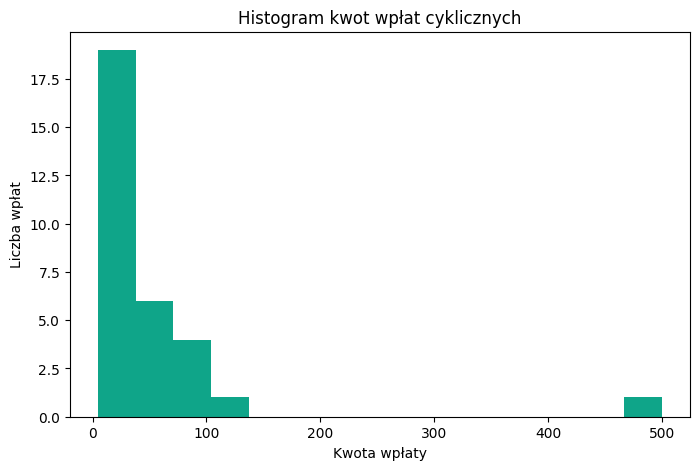

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df.wysokosc_wplaty, bins=15, color="#0fa589")
plt.xlabel("Kwota wpłaty")
plt.ylabel("Liczba wpłat")
plt.title("Histogram kwot wpłat cyklicznych")

## Wnioski końcowe
Wyniki sugerują, że strategia powinna koncentrować się na zwiększaniu liczby drobnych wpłat, przy jednoczesnym utrzymaniu mechanizmów zachęcających do większych darowizn

## Zbiór danych dotyczący działalności fundacji

In [18]:
df_2 = pd.read_csv('working_dogs_foundation-dane_2023-2025.csv')

df_2.head()

,Rok,Liczba zgłoszeń do projektu #Adopsiaki,Rodziny objęte wsparciem w projekcie #Adopsiaki,"Lokalizacje, w których trenerzy udzielali wsparcia w projekcie #Adopsiaki (kumulatywnie od początku działania Fundacji)","Liczba dzieci w szkołach i przedszkolach, które wzięły udział w warsztatach edukacyjnych",Liczba placówek objętych warsztatami,"Lokalizacje placówek, w których odbyły się warsztaty","Liczba firm, w których odbyły się warsztaty/webinary Dog Friendly Company",Lokalizacje warsztatów/eventów dla firm,Liczba wolontariuszy w Fundacji (stan na koniec roku),Obserwujący LinkedIn (stan na koniec roku),Obserwujący Facebook (stan na koniec roku),Obserwujący Instagram (stan na koniec roku),Liczba regularnych darczyńców (stan na koniec roku)
0,2023,59,11,"Warszawa, Łódź, Brzeziny, Wrocław",2726,44,NaN,5,NaN,7.0,1214.0,1242.0,1279.0,18.0
1,2024,77,45,"Warszawa, Łódź, Brzeziny, Wrocław",2835,35,NaN,9,NaN,12.0,1834.0,1537.0,1630.0,22.0
2,2025,126,63,"Wrocław, Warszawa, Łódź, Brzeziny, Gdańsk, Mys...",4846,62,od początku działania Fundacji: wojewodztwa ło...,14,"od początku działania Fundacji: Łódź, Warszawa...",16.0,2140.0,1976.0,1891.0,31.0
3,do 02.2026 włącznie,30,3,"Wrocław, Warszawa, Łódź, Brzeziny, Gdańsk, Mys...",385,5,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Tworzymy listę unikalnych lokalizacji w całym projekcie
lokalizacje_unikalne = set()
for locs in df_2['Lokalizacje, w których trenerzy udzielali wsparcia w projekcie #Adopsiaki (kumulatywnie od początku działania Fundacji)'].dropna():
    lokalizacje_unikalne.update([l.strip() for l in locs.split(',')])

flourish_df = pd.DataFrame({'Lokalizacja': list(lokalizacje_unikalne)})
flourish_df.to_csv('lokalizacje_kumulatywne_flourish.csv', index=False)

In [20]:
lokalizacje_unikalne

{'Brzeziny',
 'Bytom',
 'Gdańsk',
 'Gliwice',
 'Jelenia Góra',
 'Kraków',
 'Myszków',
 'Opole',
 'Pabianice',
 'Poddębice',
 'Tarnowskie Góry',
 'Tarnów',
 'Warszawa',
 'Wrocław',
 'Łódź'}

In [21]:
len(lokalizacje_unikalne)

15

In [22]:
df_2['Rok_str'] = df_2['Rok'].astype(str)
df_2['lokalizacje_list'] = df_2['Lokalizacje, w których trenerzy udzielali wsparcia w projekcie #Adopsiaki (kumulatywnie od początku działania Fundacji)'].str.split(',\s*')

dodane = set()
rows = []


for _, row in df_2.iterrows():
    rok = row['Rok_str']
    for loc in row['lokalizacje_list']:
        loc = loc.strip()
        if loc not in dodane:
            rows.append({'Rok': rok, 'Lokalizacja': loc})
            dodane.add(loc)

df_lokalizacje_rok = pd.DataFrame(rows)
print(df_lokalizacje_rok)

                    Rok      Lokalizacja
0                  2023         Warszawa
1                  2023             Łódź
2                  2023         Brzeziny
3                  2023          Wrocław
4                  2025           Gdańsk
5                  2025          Myszków
6                  2025          Gliwice
7                  2025            Bytom
8                  2025  Tarnowskie Góry
9                  2025            Opole
10                 2025     Jelenia Góra
11                 2025        Pabianice
12                 2025        Poddębice
13  do 02.2026 włącznie           Kraków
14  do 02.2026 włącznie           Tarnów


#### Analiza wyników
- Projekt #Adopsiaki dotarł do 15 lokalizacji w różnych województwach
- Z danych wynika że w 2024 nie przeprowadzono konsultacji w nowych miastach
- W 2026 rozszerzono działalność o nowe województwo - małopolskie.

## Dane Finansowe

In [23]:
df_3 = pd.read_csv('working_dogs_foundation-dane_finansowe.csv')

display(df_3)

,Kategoria główna,Kategoria szczegółowa,2023,2024,2025
0,Przychody z nieodpłatnej działalności pożytku ...,Granty,0,"9901,04",21444
1,Przychody z nieodpłatnej działalności pożytku ...,Darczyńcy indywidualni,"11020,8",47244,"82435,35"
2,Przychody z nieodpłatnej działalności pożytku ...,Darczyńcy biznesowi,12666,31043,16887
3,Przychody z nieodpłatnej działalności pożytku ...,Zbiórki publiczne,4630,9100,"31233,58"
4,Przychody z nieodpłatnej działalności pożytku ...,"1,5% podatku (OPP)",0,"6055,6","15162,6"
5,Przychody z nieodpłatnej działalności pożytku ...,Pozostałe darowizny,"2646,22","10366,53","32015,89"
6,Przychody z odpłatnej działalności pożytku pub...,NaN,15010,7100,27790
7,Przychody z działalności gospodarczej,NaN,"72820,47",58045,69935
8,Pozostałe przychody operacyjne,NaN,"1624,3","1716,93",642
9,SUMA PRZYCHODÓW FUNDACJI,NaN,"120417,79","180572,1","297545,42"


In [24]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Kategoria główna       12 non-null     object
 1   Kategoria szczegółowa  6 non-null      object
 2   2023                   12 non-null     object
 3   2024                   12 non-null     object
 4   2025                   12 non-null     object
dtypes: object(5)
memory usage: 608.0+ bytes


### Przygotowanie zbioru danych

In [25]:
df_3.columns

Index(['Kategoria główna', 'Kategoria szczegółowa', '2023', '2024', '2025'], dtype='object')

In [26]:
df_3.describe() # widzimy błędny format danych

,Kategoria główna,Kategoria szczegółowa,2023,2024,2025
count,12,6,12,12,12
unique,7,6,11,12,12
top,Przychody z nieodpłatnej działalności pożytku ...,Granty,0,"9901,04",21444
freq,6,1,2,1,1


In [27]:
for col in ['2023', '2024', '2025']:
    df_3[col] = pd.to_numeric(
        df_3[col].str.replace(' ', '').str.replace(',', '.'), 
        errors='coerce'
    )

In [28]:
df_3.iloc[:,2:].describe()

,2023,2024,2025
count,12.000000,12.000000,12.00000
mean,30104.447500,45143.025000,74386.35500
std,45548.762768,65540.098246,105202.88279
min,0.000000,1256.230000,642.00000
25%,2390.740000,6838.900000,16455.90000
50%,7989.745000,10133.785000,29511.79000
75%,29462.617500,49944.250000,73060.08750
max,120417.790000,180572.100000,297545.42000


In [29]:
df_3['Kategoria główna']

0     Przychody z nieodpłatnej działalności pożytku ...
1     Przychody z nieodpłatnej działalności pożytku ...
2     Przychody z nieodpłatnej działalności pożytku ...
3     Przychody z nieodpłatnej działalności pożytku ...
4     Przychody z nieodpłatnej działalności pożytku ...
5     Przychody z nieodpłatnej działalności pożytku ...
6     Przychody z odpłatnej działalności pożytku pub...
7                 Przychody z działalności gospodarczej
8                        Pozostałe przychody operacyjne
9                              SUMA PRZYCHODÓW FUNDACJI
10                                SUMA KOSZTÓW FUNDACJI
11                                      WYNIK FINANSOWY
Name: Kategoria główna, dtype: object

In [30]:
df_3['Kategoria'] = df_3['Kategoria szczegółowa'].fillna(df_3['Kategoria główna'])

In [31]:
df_3

,Kategoria główna,Kategoria szczegółowa,2023,2024,2025,Kategoria
0,Przychody z nieodpłatnej działalności pożytku ...,Granty,0.00,9901.04,21444.00,Granty
1,Przychody z nieodpłatnej działalności pożytku ...,Darczyńcy indywidualni,11020.80,47244.00,82435.35,Darczyńcy indywidualni
2,Przychody z nieodpłatnej działalności pożytku ...,Darczyńcy biznesowi,12666.00,31043.00,16887.00,Darczyńcy biznesowi
3,Przychody z nieodpłatnej działalności pożytku ...,Zbiórki publiczne,4630.00,9100.00,31233.58,Zbiórki publiczne
4,Przychody z nieodpłatnej działalności pożytku ...,"1,5% podatku (OPP)",0.00,6055.60,15162.60,"1,5% podatku (OPP)"
5,Przychody z nieodpłatnej działalności pożytku ...,Pozostałe darowizny,2646.22,10366.53,32015.89,Pozostałe darowizny
6,Przychody z odpłatnej działalności pożytku pub...,NaN,15010.00,7100.00,27790.00,Przychody z odpłatnej działalności pożytku pub...
7,Przychody z działalności gospodarczej,NaN,72820.47,58045.00,69935.00,Przychody z działalności gospodarczej
8,Pozostałe przychody operacyjne,NaN,1624.30,1716.93,642.00,Pozostałe przychody operacyjne
9,SUMA PRZYCHODÓW FUNDACJI,NaN,120417.79,180572.10,297545.42,SUMA PRZYCHODÓW FUNDACJI


### Usunięcie wierszy sumarycznych

In [32]:
df_clean = df_3[~df_3['Kategoria główna'].str.contains('SUMA|WYNIK', na=False)]

In [33]:
df_clean

,Kategoria główna,Kategoria szczegółowa,2023,2024,2025,Kategoria
0,Przychody z nieodpłatnej działalności pożytku ...,Granty,0.00,9901.04,21444.00,Granty
1,Przychody z nieodpłatnej działalności pożytku ...,Darczyńcy indywidualni,11020.80,47244.00,82435.35,Darczyńcy indywidualni
2,Przychody z nieodpłatnej działalności pożytku ...,Darczyńcy biznesowi,12666.00,31043.00,16887.00,Darczyńcy biznesowi
3,Przychody z nieodpłatnej działalności pożytku ...,Zbiórki publiczne,4630.00,9100.00,31233.58,Zbiórki publiczne
4,Przychody z nieodpłatnej działalności pożytku ...,"1,5% podatku (OPP)",0.00,6055.60,15162.60,"1,5% podatku (OPP)"
5,Przychody z nieodpłatnej działalności pożytku ...,Pozostałe darowizny,2646.22,10366.53,32015.89,Pozostałe darowizny
6,Przychody z odpłatnej działalności pożytku pub...,NaN,15010.00,7100.00,27790.00,Przychody z odpłatnej działalności pożytku pub...
7,Przychody z działalności gospodarczej,NaN,72820.47,58045.00,69935.00,Przychody z działalności gospodarczej
8,Pozostałe przychody operacyjne,NaN,1624.30,1716.93,642.00,Pozostałe przychody operacyjne


### Przychody według kategorii dla 2025 roku

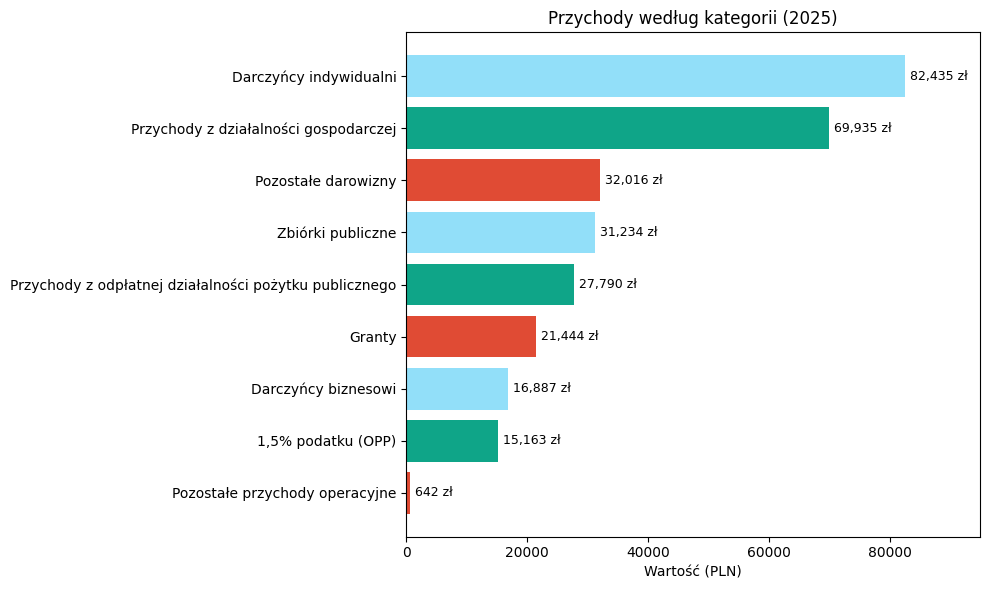

In [34]:
df_bar = df_clean[['Kategoria', '2025']].copy()
df_bar = df_bar.sort_values('2025', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_bar['Kategoria'], df_bar['2025'], color=colors[:len(df_bar)])

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(df_bar['2025']) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f} zł',
        va='center', ha='left', fontsize=9
    )

plt.title('Przychody według kategorii (2025)')
plt.xlabel('Wartość (PLN)')
plt.xlim(0, max(df_bar['2025']) * 1.15)
plt.tight_layout()
plt.show()

### Przychody według kategorii - posortowane według 2023 roku

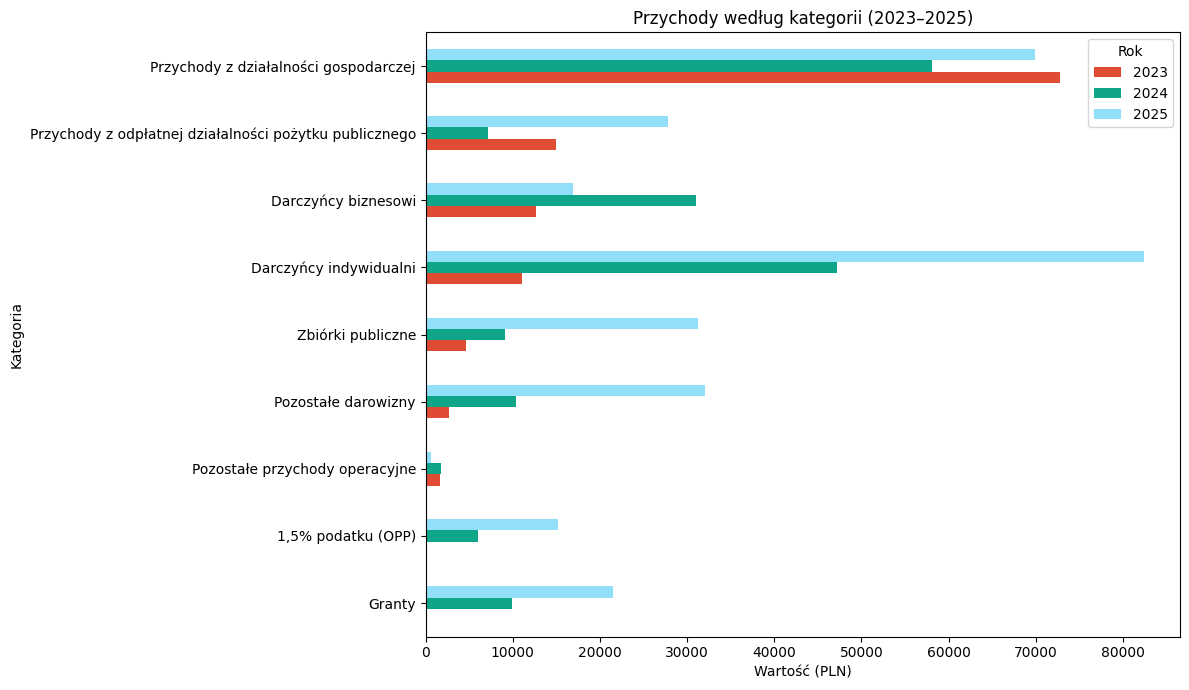

In [35]:
df_bar2 = df_clean[['Kategoria', '2023', '2024', '2025']].copy()
df_bar2 = df_bar2.sort_values('2023', ascending=True)
df_bar2 = df_bar2.set_index('Kategoria')

df_bar2.plot(
    kind='barh',
    figsize=(12, 7),
    color=colors[:3]
)

plt.title('Przychody według kategorii (2023–2025)')
plt.xlabel('Wartość (PLN)')
plt.legend(title='Rok', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

#### Analiza wykresu
-  1,5% podatku — nowe źródło od 2024
-  Zmiana głównego źródła przychodów
-  W latach 2023–2024 dominowała działalność gospodarcza, ale w 2025 roku po raz pierwszy to darczyńcy indywidualni stali się największym źródłem przychodów
-  Pozostałe przychody operacyjne — jedyny spadek

In [36]:
df_long = df_clean.melt(
    id_vars='Kategoria',
    value_vars=['2023', '2024', '2025'],
    var_name='Rok',
    value_name='Wartość'
)

df_long

,Kategoria,Rok,Wartość
0,Granty,2023,0.00
1,Darczyńcy indywidualni,2023,11020.80
2,Darczyńcy biznesowi,2023,12666.00
3,Zbiórki publiczne,2023,4630.00
4,"1,5% podatku (OPP)",2023,0.00
5,Pozostałe darowizny,2023,2646.22
6,Przychody z odpłatnej działalności pożytku pub...,2023,15010.00
7,Przychody z działalności gospodarczej,2023,72820.47
8,Pozostałe przychody operacyjne,2023,1624.30
9,Granty,2024,9901.04


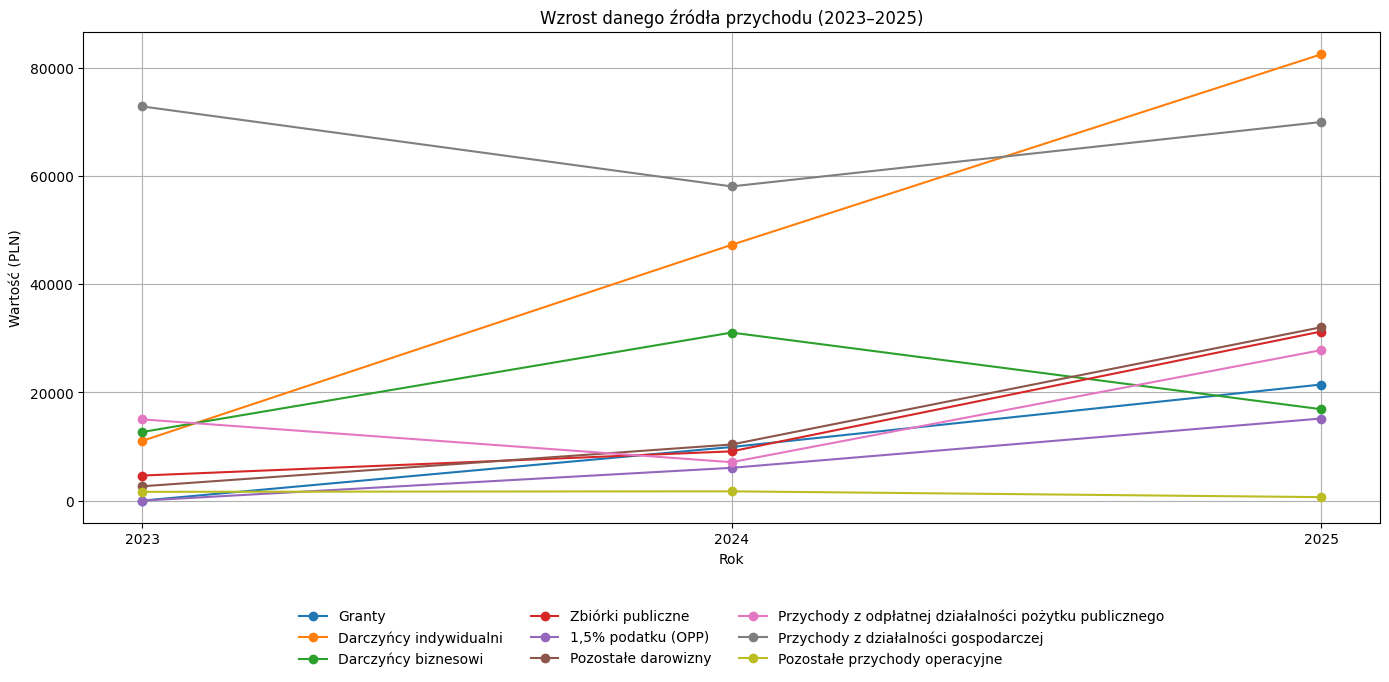

In [37]:
plt.figure(figsize=(14, 7))

for kategoria in df_long['Kategoria'].unique():
    dane = df_long[df_long['Kategoria'] == kategoria]
    plt.plot(dane['Rok'], dane['Wartość'], marker='o', label=kategoria)

plt.title('Wzrost danego źródła przychodu (2023–2025)')
plt.xlabel('Rok')
plt.ylabel('Wartość (PLN)')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)
plt.grid(True)
plt.tight_layout()
plt.show()

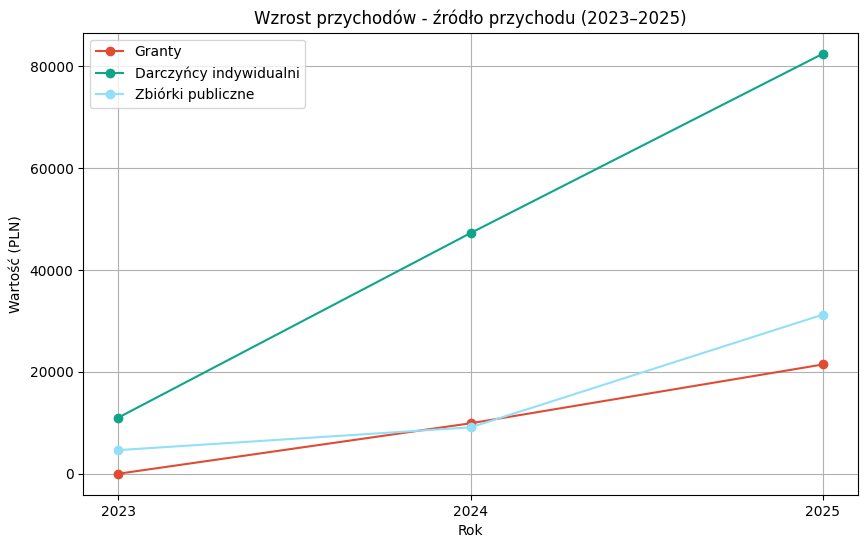

In [38]:
wybrane_kategorie = ['Granty', 'Darczyńcy indywidualni', 'Darczyńcy Biznesowi', 'Zbiórki publiczne']
df_plot = df_long[df_long['Kategoria'].isin(wybrane_kategorie)]

plt.figure(figsize=(10, 6))
for i, kategoria in enumerate(df_plot['Kategoria'].unique()):
    dane = df_plot[df_plot['Kategoria'] == kategoria]
    plt.plot(dane['Rok'], dane['Wartość'], marker='o', label=kategoria, color=colors[i])

plt.title('Wzrost przychodów - źródło przychodu (2023–2025)')
plt.xlabel('Rok')
plt.ylabel('Wartość (PLN)')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
df_flourish = df_clean[['Kategoria', '2023', '2024', '2025']].copy()

# % change 2023 -> 2025 (jak w przykładzie 2004->2020)
df_flourish['% change (2023 to 2025)'] = (
    (df_flourish['2025'] - df_flourish['2023']) / df_flourish['2023'] * 100
).round(2)

# Direction
df_flourish['Direction'] = df_flourish['% change (2023 to 2025)'].apply(
    lambda x: 'Up' if x > 0 else 'Down'
)

# edge case: Granty miały 0 w 2023 - dzielenie przez zero
df_flourish['% change (2023 to 2025)'] = df_flourish['% change (2023 to 2025)'].replace(
    [float('inf'), float('-inf')], None
)

display(df_flourish)

,Kategoria,2023,2024,2025,% change (2023 to 2025),Direction
0,Granty,0.00,9901.04,21444.00,None,Up
1,Darczyńcy indywidualni,11020.80,47244.00,82435.35,648.0,Up
2,Darczyńcy biznesowi,12666.00,31043.00,16887.00,33.33,Up
3,Zbiórki publiczne,4630.00,9100.00,31233.58,574.59,Up
4,"1,5% podatku (OPP)",0.00,6055.60,15162.60,None,Up
5,Pozostałe darowizny,2646.22,10366.53,32015.89,1109.87,Up
6,Przychody z odpłatnej działalności pożytku pub...,15010.00,7100.00,27790.00,85.14,Up
7,Przychody z działalności gospodarczej,72820.47,58045.00,69935.00,-3.96,Down
8,Pozostałe przychody operacyjne,1624.30,1716.93,642.00,-60.48,Down


In [41]:
df_flourish.to_csv('przychody_flourish.csv', index=False)

In [42]:
top3 = df_flourish.nlargest(3, '2025')[['Kategoria', '2023', '2024', '2025', '% change (2023 to 2025)', 'Direction']]
print(top3)

                               Kategoria      2023      2024      2025  \
1                 Darczyńcy indywidualni  11020.80  47244.00  82435.35   
7  Przychody z działalności gospodarczej  72820.47  58045.00  69935.00   
5                    Pozostałe darowizny   2646.22  10366.53  32015.89   

  % change (2023 to 2025) Direction  
1                   648.0        Up  
7                   -3.96      Down  
5                 1109.87        Up  


In [43]:
top3.to_csv('przychody_flourish_top3.csv', index=False)